# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [9]:
# Import the library
from PIL import Image
from skimage import data

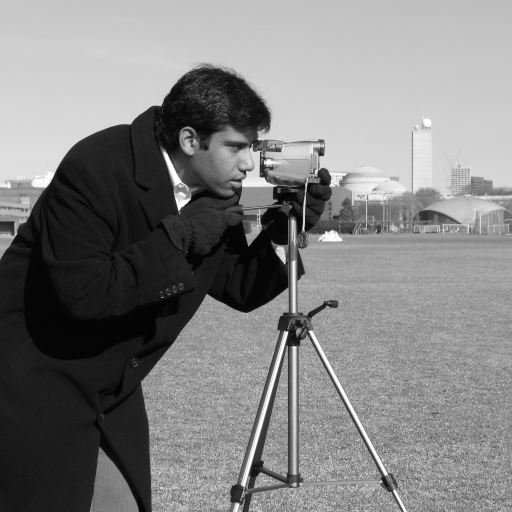

In [10]:
# ── Load image ────────────────────────────────────
image = Image.fromarray(data.camera())
display(image)


### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [14]:
# Get the size of the image

# scaling factors
width, height = image.size
cx = 2
cy = 2

In [15]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scaled_image = image.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)


Original image size: (512, 512)
Scaled image size: (1024, 1024)


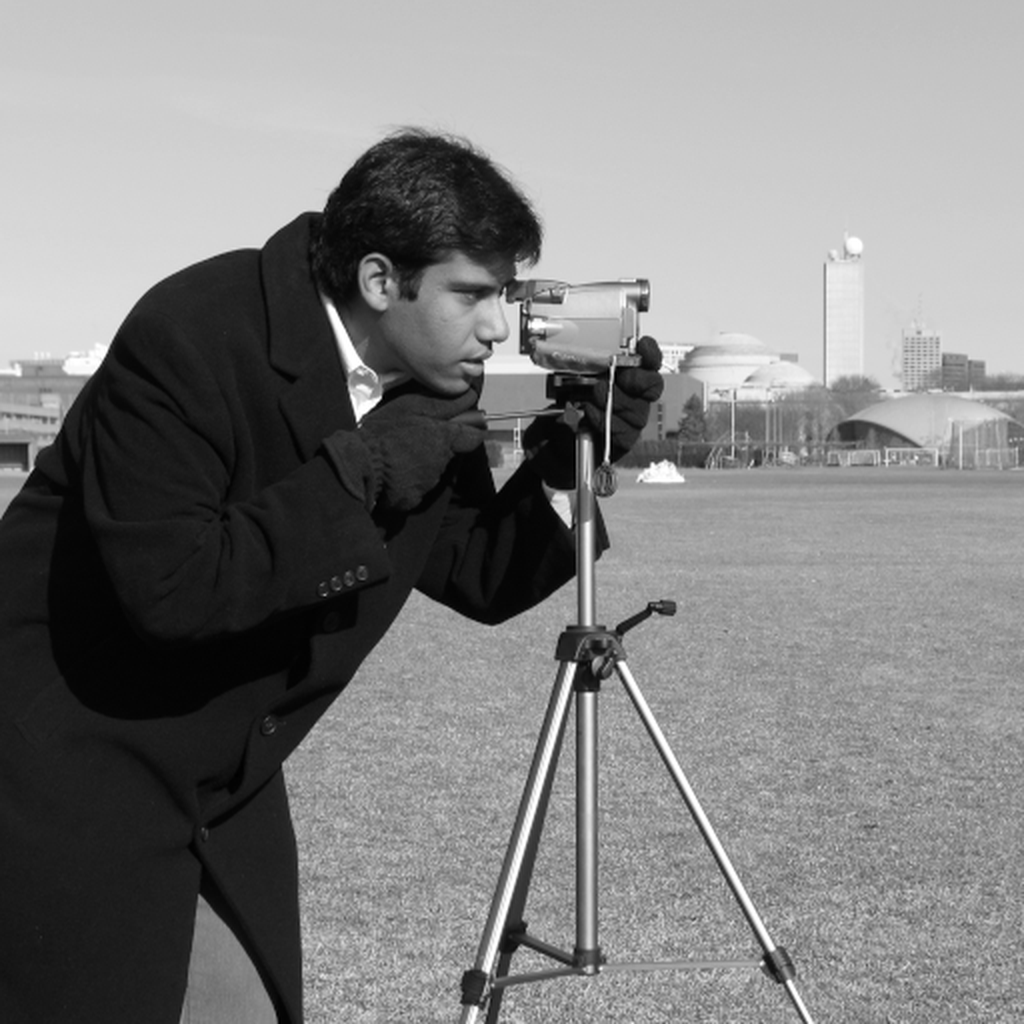

In [16]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_image.save("task1_1_scaled.jpg")

print("Original image size:", image.size)
print("Scaled image size:", scaled_image.size)

display(scaled_image)

 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [17]:
cx = 2
cy = 1

In [18]:
non_uniform_scaled_image = image.resize(
    (int(width * cx), int(height * cy)),
    Image.Resampling.LANCZOS
)

Original image size: (512, 512)
Non-uniform scaled size: (1024, 512)


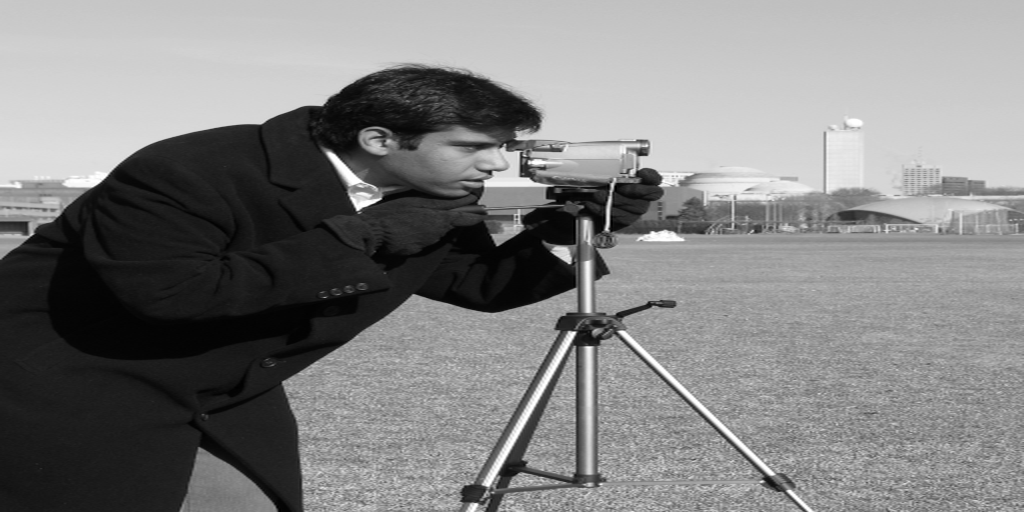

In [19]:
print("Original image size:", image.size)
print("Non-uniform scaled size:", non_uniform_scaled_image.size)

display(non_uniform_scaled_image)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original image size: (512, 512)
Rotated image size: (700, 700)


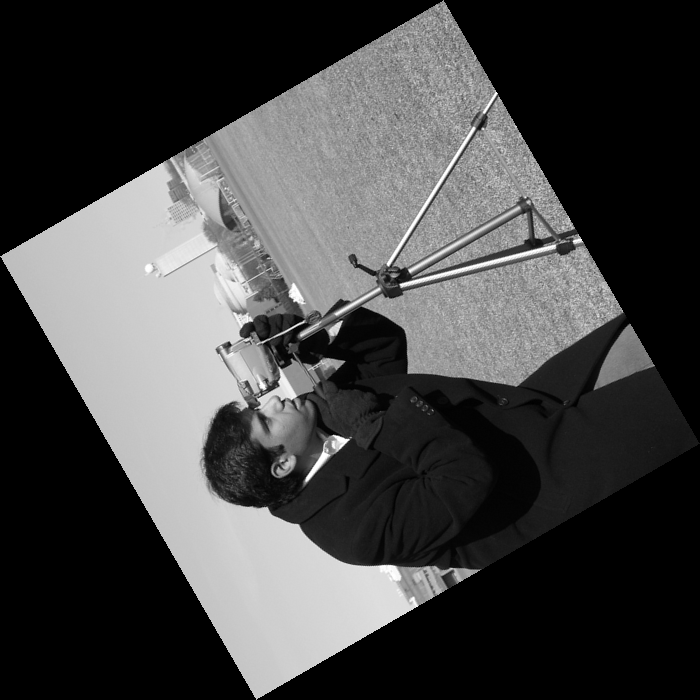

In [20]:
# ── 2. Rotate 120 degrees ──────────────────────────
# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")
rotated_image = image.rotate(
    120,
    resample=Image.Resampling.BICUBIC,
    expand=True
)

rotated_image.save("task1_2_rotated.jpg")

print("Original image size:", image.size)
print("Rotated image size:", rotated_image.size)

display(rotated_image)

### 3. Shear

In [21]:
# -- c. Get the image dimensions ────────────────────
width, height = image.size

In [22]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5

new_width = width + int(abs(shear_factor) * height)

shear_matrix = (
    1, -shear_factor, 0,
    0, 1, 0
)

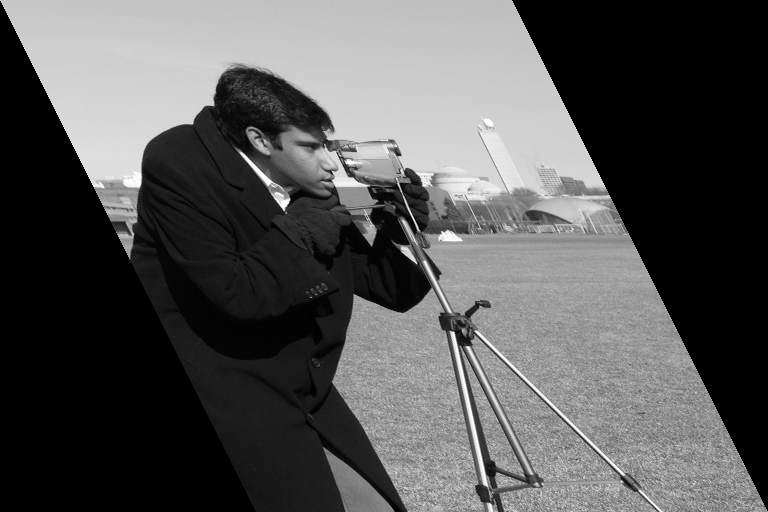

In [23]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]
sheared_image = image.transform(
    (new_width, height),
    Image.Transform.AFFINE,
    shear_matrix,
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

display(sheared_image)

In [24]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_image.save("task1_3_sheared.jpg")

print("Original image size:", image.size)
print("Sheared image size:", sheared_image.size)

Original image size: (512, 512)
Sheared image size: (768, 512)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

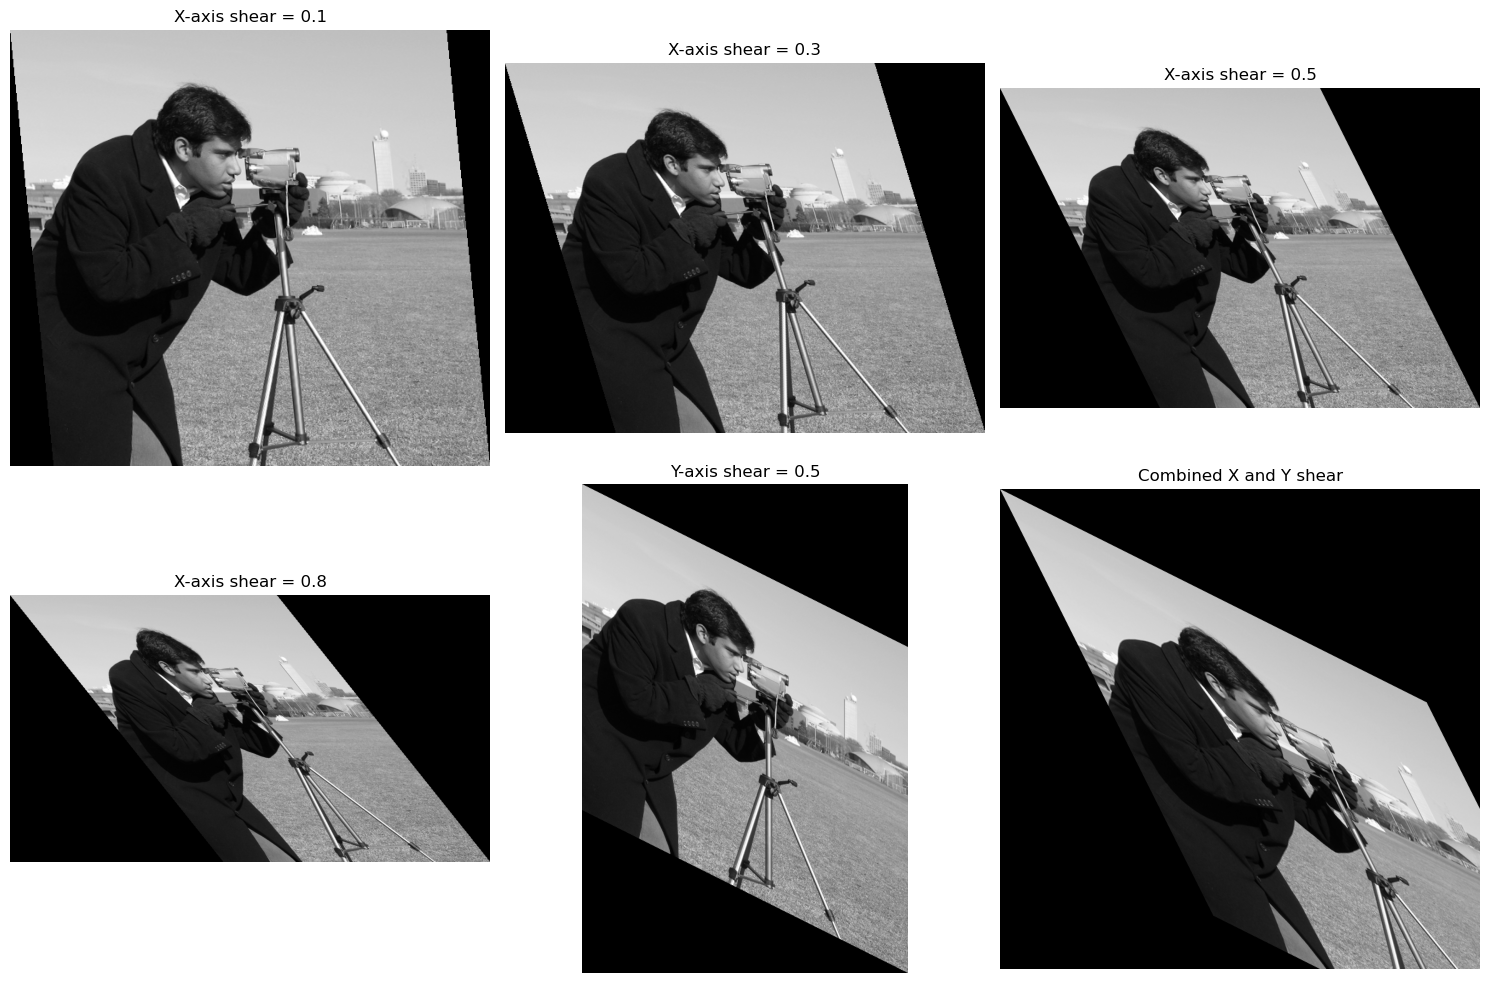

In [25]:
factors = [0.1, 0.3, 0.5, 0.8]

plt.figure(figsize=(15, 10))

# Compare different X-axis shear factors
for i, factor in enumerate(factors):
    canvas_width = width + int(abs(factor) * height)

    result = image.transform(
        (canvas_width, height),
        Image.Transform.AFFINE,
        (1, -factor, 0, 0, 1, 0),
        resample=Image.Resampling.BICUBIC,
        fillcolor=0
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(result, cmap="gray")
    plt.title(f"X-axis shear = {factor}")
    plt.axis("off")

# Y-axis shear
factor = 0.5
canvas_height = height + int(abs(factor) * width)

y_sheared = image.transform(
    (width, canvas_height),
    Image.Transform.AFFINE,
    (1, 0, 0, -factor, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

plt.subplot(2, 3, 5)
plt.imshow(y_sheared, cmap="gray")
plt.title("Y-axis shear = 0.5")
plt.axis("off")

# Combined X-axis and Y-axis shear
combined_sheared = image.transform(
    (
        width + int(abs(factor) * height),
        height + int(abs(factor) * width)
    ),
    Image.Transform.AFFINE,
    (1, -factor, 0, -factor, 1, 0),
    resample=Image.Resampling.BICUBIC,
    fillcolor=0
)

plt.subplot(2, 3, 6)
plt.imshow(combined_sheared, cmap="gray")
plt.title("Combined X and Y shear")
plt.axis("off")

plt.tight_layout()
plt.show()

# Intensity Transformations
Negative · Log · Power Law (Gamma)

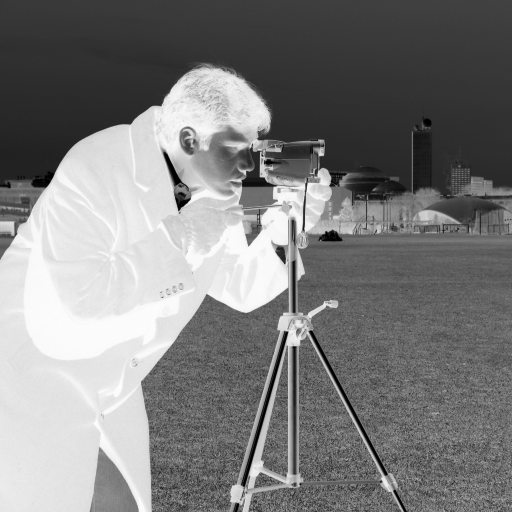

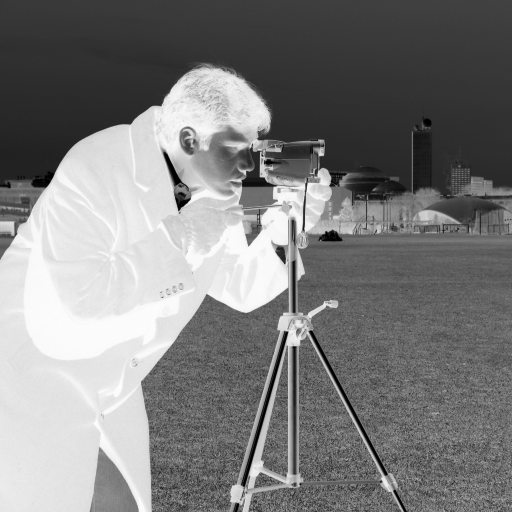

In [27]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np

image_array = np.array(image)
negative_array = 255 - image_array
negative_numpy = Image.fromarray(negative_array.astype(np.uint8))

display(negative_numpy)
image_array = np.array(image, dtype=np.uint8)
negative_array = 255 - image_array
negative_numpy = Image.fromarray(negative_array)

display(negative_numpy)



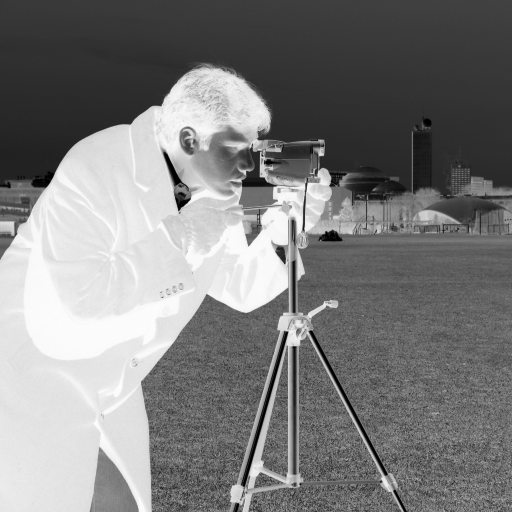

In [28]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_pil = ImageOps.invert(image.convert("L"))

display(negative_pil)

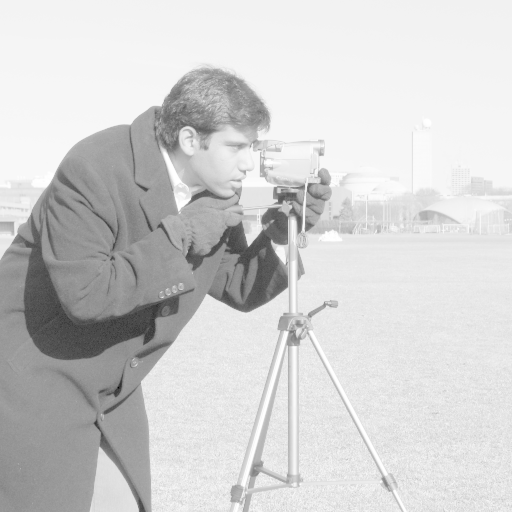

In [29]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)



# Apply the log transformation to each pixel
arr = np.array(image, dtype=np.float32)

c = 255 / np.log1p(255)
log_transformed_array = c * np.log1p(arr)

log_transformed_array = np.clip(
    log_transformed_array, 0, 255
).astype(np.uint8)

log_transformed_image = Image.fromarray(log_transformed_array)

display(log_transformed_image)

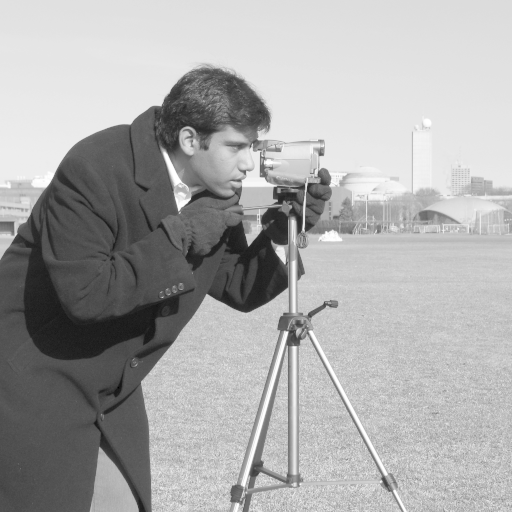

In [30]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

gamma_transformed_array = 255 * np.power(
    arr / 255.0,
    gamma
)

gamma_transformed_array = np.clip(
    gamma_transformed_array, 0, 255
).astype(np.uint8)

gamma_transformed_image = Image.fromarray(gamma_transformed_array)

display(gamma_transformed_image)
